In [3]:
import os
import re
import json
import time
import platform
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
SEED = 42
np.random.seed(SEED)
OUT = 'lab05_outputs'
os.makedirs(OUT, exist_ok=True)
print(platform.python_version())

3.13.5


## 1. Dataset configuration and loading

In [8]:
DATA_PATH = '/home/matlab/Downloads/Tweets.csv'

In [9]:
TEXT_COL = 'text'
TARGET_COL = 'airline_sentiment'
ID_COL = 'tweet_id'
ENTITY_COL = 'airline'

In [10]:
raw = pd.read_csv(DATA_PATH)
required = {TEXT_COL, TARGET_COL}
missing = required - set(raw.columns)
assert not missing, missing

In [11]:
keep_cols = [c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL] if c in raw.columns]
df = raw[keep_cols].copy()
df = df.dropna(subset=[TEXT_COL, TARGET_COL])
df[TEXT_COL] = df[TEXT_COL].astype(str)
df.shape

(14640, 4)

In [12]:
df.head()

,tweet_id,text,airline_sentiment,airline
0,570306133677760513,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,570301130888122368,@VirginAmerica plus you've added commercials t...,positive,Virgin America
2,570301083672813571,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America
3,570301031407624196,@VirginAmerica it's really aggressive to blast...,negative,Virgin America
4,570300817074462722,@VirginAmerica and it's a really big bad thing...,negative,Virgin America


## 2. Dataset Audit

In [13]:
print(df.shape)
print(df.columns.tolist())
print(df[TARGET_COL].value_counts(dropna=False))
print(df.isna().sum())
print('Duplicate IDs', df[ID_COL].duplicated().sum() if ID_COL in df.columns else 'N/A')
print('Duplicate text', df[TEXT_COL].duplicated().sum())

(14640, 4)
['tweet_id', 'text', 'airline_sentiment', 'airline']
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
tweet_id             0
text                 0
airline_sentiment    0
airline              0
dtype: int64
Duplicate IDs 155
Duplicate text 213


## 3. Leakage and identifier removal

## 4. Minimal tweet normalization

In [15]:
def normalize_tweet(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' URLTOKEN ', text)
    text = re.sub(r'@\w+', ' USERTOKEN ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df[TEXT_COL].map(normalize_tweet)
print('Duplicate clean text', df['clean_text'].duplicated().sum())
df[['clean_text', TARGET_COL]].head(5)

Duplicate clean text 336


,clean_text,airline_sentiment
0,USERTOKEN What USERTOKEN said.,neutral
1,USERTOKEN plus you've added commercials to the...,positive
2,USERTOKEN I didn't today... Must mean I need t...,neutral
3,USERTOKEN it's really aggressive to blast obno...,negative
4,USERTOKEN and it's a really big bad thing abou...,negative


## 5. Exploratory visualizations

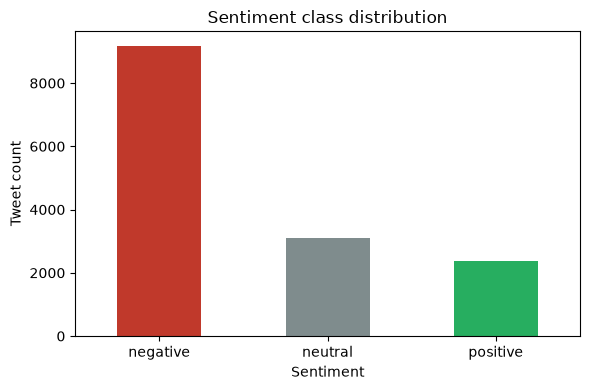

In [16]:
class_counts = df[TARGET_COL].value_counts()
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['#c0392b', '#7f8c8d', '#27ae60'])
plt.title('Sentiment class distribution')
plt.xlabel('Sentiment')
plt.ylabel('Tweet count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

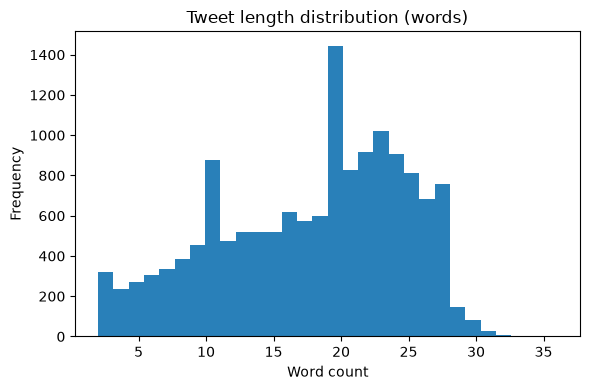

In [17]:
df['tweet_length'] = df['clean_text'].str.split().map(len)
plt.figure(figsize=(6, 4))
plt.hist(df['tweet_length'], bins=30, color='#2980b9')
plt.title('Tweet length distribution (words)')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 6. Fixed stratified split

In [22]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df[TARGET_COL])

In [23]:
train_df.to_csv(os.path.join(OUT, 'train_manifest.csv'), index=False)
test_df.to_csv(os.path.join(OUT, 'test_manifest.csv'), index=False)

In [24]:
X_train, y_train = train_df['clean_text'], train_df[TARGET_COL]
X_test, y_test = test_df['clean_text'], test_df[TARGET_COL]
print(X_train.shape, X_test.shape)

(11712,) (2928,)


## 7. Top terms by class (training data only)

In [25]:
top_vectorizer = TfidfVectorizer(ngram_range=(1, 1), min_df=3, max_df=0.95, stop_words='english')
top_matrix = top_vectorizer.fit_transform(X_train)
feature_names = np.array(top_vectorizer.get_feature_names_out())

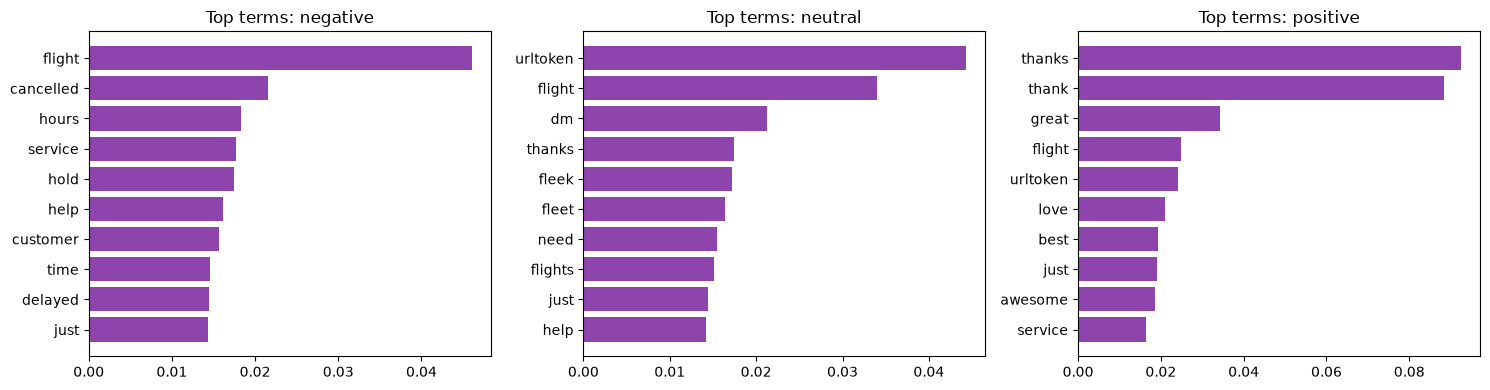

In [26]:
fig, axes = plt.subplots(1, len(class_counts.index), figsize=(5 * len(class_counts.index), 4))
if len(class_counts.index) == 1:
    axes = [axes]
for ax, cls in zip(axes, sorted(y_train.unique())):
    mask = (y_train.values == cls)
    mean_scores = np.asarray(top_matrix[mask].mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[-10:]
    ax.barh(feature_names[top_idx], mean_scores[top_idx], color='#8e44ad')
    ax.set_title('Top terms: ' + str(cls))
plt.tight_layout()
plt.show()

## 8. Baselines: Dummy and VADER

In [28]:
dummy = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2)),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=SEED))
])

In [29]:
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_macro_f1 = f1_score(y_test, dummy_pred, average='macro')
print('Dummy macro F1', dummy_macro_f1)

Dummy macro F1 0.256840926586885


In [30]:
analyzer = SentimentIntensityAnalyzer()

In [31]:
def vader_label(text):
    compound = analyzer.polarity_scores(text)['compound']
    if compound >= 0.05:
        return 'positive'
    if compound <= -0.05:
        return 'negative'
    return 'neutral'

In [32]:
vader_pred = X_test.map(vader_label)
vader_macro_f1 = f1_score(y_test, vader_pred, average='macro')
print('VADER macro F1', vader_macro_f1)

VADER macro F1 0.5206462567349533


## 9. Classical models and cross validation

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [34]:
models = {
    'MultinomialNB': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.98, sublinear_tf=True)),
        ('clf', MultinomialNB(alpha=0.5))
    ]),
    'LogisticRegression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.98, sublinear_tf=True)),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.98, sublinear_tf=True)),
        ('clf', LinearSVC(class_weight='balanced', random_state=SEED))
    ])
}

In [35]:
rows = []
for name, pipe in models.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted', 'accuracy': 'accuracy'},
        n_jobs=-1, return_train_score=False
    )
    rows.append({
        'model': name,
        'macro_f1_mean': scores['test_macro_f1'].mean(),
        'macro_f1_sd': scores['test_macro_f1'].std(),
        'weighted_f1_mean': scores['test_weighted_f1'].mean(),
        'accuracy_mean': scores['test_accuracy'].mean(),
        'fit_time_mean': scores['fit_time'].mean()
    })

rows.append({
    'model': 'Dummy',
    'macro_f1_mean': dummy_macro_f1,
    'macro_f1_sd': np.nan,
    'weighted_f1_mean': np.nan,
    'accuracy_mean': accuracy_score(y_test, dummy_pred),
    'fit_time_mean': np.nan
})
rows.append({
    'model': 'VADER',
    'macro_f1_mean': vader_macro_f1,
    'macro_f1_sd': np.nan,
    'weighted_f1_mean': np.nan,
    'accuracy_mean': accuracy_score(y_test, vader_pred),
    'fit_time_mean': np.nan
})

/home/matlab/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/matlab/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/matlab/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/matlab/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.

In [36]:
cv_results = pd.DataFrame(rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
cv_results.to_csv(os.path.join(OUT, 'cv_results.csv'), index=False)
cv_results

,model,macro_f1_mean,macro_f1_sd,weighted_f1_mean,accuracy_mean,fit_time_mean
0,LogisticRegression,0.744578,0.008028,0.795607,0.792947,1.993403
1,LinearSVC,0.739161,0.011288,0.796678,0.800460,1.050552
2,MultinomialNB,0.585816,0.015062,0.690117,0.736339,0.612573
3,VADER,0.520646,NaN,NaN,0.552254,NaN
4,Dummy,0.256841,NaN,NaN,0.626708,NaN


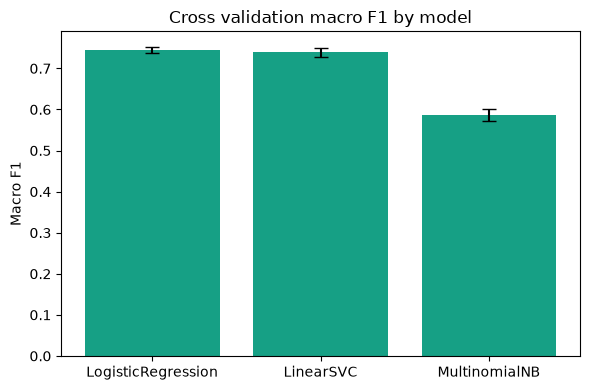

In [37]:
plot_results = cv_results[cv_results['model'].isin(['MultinomialNB', 'LogisticRegression', 'LinearSVC'])]
plt.figure(figsize=(6, 4))
plt.bar(plot_results['model'], plot_results['macro_f1_mean'], yerr=plot_results['macro_f1_sd'], color='#16a085', capsize=5)
plt.title('Cross validation macro F1 by model')
plt.ylabel('Macro F1')
plt.tight_layout()
plt.show()

## 10. Model selection and locked test evaluation

In [39]:
learned_results = cv_results[cv_results['model'].isin(models.keys())].reset_index(drop=True)

In [40]:
best_name = learned_results.iloc[0]['model']
best_model = models[best_name]
best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)

In [41]:
print('Selected model', best_name)
print(classification_report(y_test, test_pred, digits=4))

Selected model LogisticRegression
              precision    recall  f1-score   support

    negative     0.8910    0.8420    0.8658      1835
     neutral     0.5907    0.7145    0.6467       620
    positive     0.7432    0.6977    0.7197       473

    accuracy                         0.7917      2928
   macro avg     0.7416    0.7514    0.7441      2928
weighted avg     0.8035    0.7917    0.7958      2928



In [42]:
macro_f1_test = f1_score(y_test, test_pred, average='macro')
weighted_f1_test = f1_score(y_test, test_pred, average='weighted')
accuracy_test = accuracy_score(y_test, test_pred)

In [43]:
print('Macro F1', macro_f1_test)
print('Weighted F1', weighted_f1_test)
print('Accuracy', accuracy_test)

Macro F1 0.74408078059935
Weighted F1 0.7958067075994532
Accuracy 0.7916666666666666


In [44]:
labels_sorted = sorted(y_test.unique())
cm_counts = confusion_matrix(y_test, test_pred, labels=labels_sorted)
cm_normalized = confusion_matrix(y_test, test_pred, labels=labels_sorted, normalize='true')

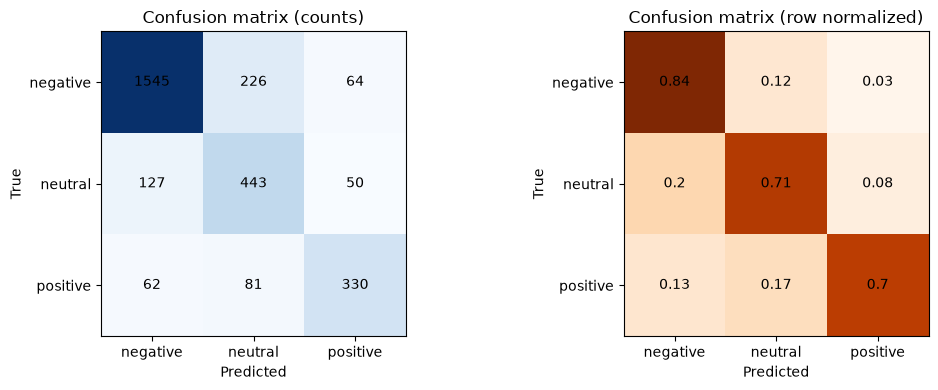

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(cm_counts, cmap='Blues')
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xticks(range(len(labels_sorted)))
axes[0].set_yticks(range(len(labels_sorted)))
axes[0].set_xticklabels(labels_sorted)
axes[0].set_yticklabels(labels_sorted)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        axes[0].text(j, i, cm_counts[i, j], ha='center', va='center')

im1 = axes[1].imshow(cm_normalized, cmap='Oranges')
axes[1].set_title('Confusion matrix (row normalized)')
axes[1].set_xticks(range(len(labels_sorted)))
axes[1].set_yticks(range(len(labels_sorted)))
axes[1].set_xticklabels(labels_sorted)
axes[1].set_yticklabels(labels_sorted)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        axes[1].text(j, i, round(cm_normalized[i, j], 2), ha='center', va='center')

plt.tight_layout()
plt.show()

In [46]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_pred, labels=labels_sorted)
class_report_df = pd.DataFrame({
    'class': labels_sorted,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': support
})

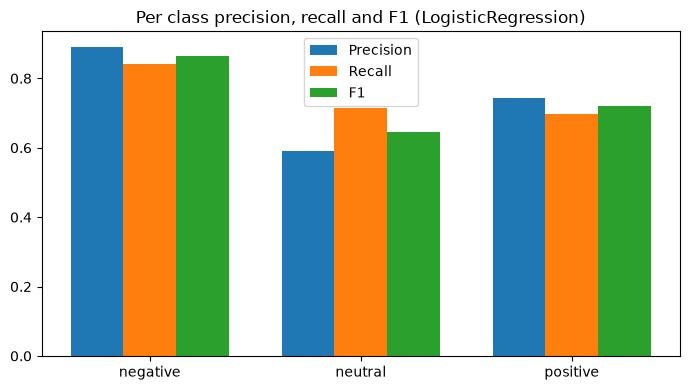

In [48]:
x = np.arange(len(labels_sorted))
width = 0.25
plt.figure(figsize=(7, 4))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1')
plt.xticks(x, labels_sorted)
plt.title('Per class precision, recall and F1 (' + best_name + ')')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
class_report_df

,class,precision,recall,f1,support
0,negative,0.891003,0.841962,0.865789,1835
1,neutral,0.590667,0.714516,0.646715,620
2,positive,0.743243,0.697674,0.719738,473


## 11. Error analysis

In [50]:
error_mask = (test_pred != y_test.values)
error_df = test_df.loc[y_test.index[error_mask], [c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL] if c in test_df.columns]].copy()
error_df['prediction'] = test_pred[error_mask]
error_sample = error_df.sample(n=min(10, len(error_df)), random_state=SEED)
error_sample['challenge_type'] = ''
error_sample['likely_reason'] = ''
error_sample['mitigation'] = ''
error_sample.to_csv(os.path.join(OUT, 'error_analysis.csv'), index=False)
error_sample

,tweet_id,text,airline_sentiment,airline,prediction,challenge_type,likely_reason,mitigation
3723,568168460468895745,@united well it IS John Hughes' birthday. But ...,positive,United,negative,,,
2805,568892505829347329,@united we can't all be american airlines I su...,negative,United,neutral,,,
5095,569347934866636800,@SouthwestAir are you hiring for flight attend...,neutral,Southwest,negative,,,
5712,568784436428300290,@SouthwestAir Jackpot! #legroom http://t.co/Z...,positive,Southwest,neutral,,,
12623,570085625061384192,@americanair flight veers off icy runway at @d...,negative,American,neutral,,,
2950,568818335200223232,@united can't wait!!! 787!!! @tpallini http://...,positive,United,neutral,,,
915,570016325667557376,@united @reebok @rockinwellness @ Denver Inter...,positive,United,neutral,,,
3151,568632754939805696,@United What's your phone number? Customer ser...,neutral,United,negative,,,
3979,567894187900710912,"@united Great, thank you!! I'll send it now.",neutral,United,positive,,,
3687,568186071114252288,@united have reported it. Still in Istanbul a...,positive,United,negative,,,


## 12. Product and entity level analysis

In [51]:
MIN_SUPPORT = 30
pred_df = test_df[[c for c in [ID_COL, TEXT_COL, TARGET_COL, ENTITY_COL] if c in test_df.columns]].copy()
pred_df['prediction'] = test_pred
pred_df['correct'] = pred_df['prediction'] == pred_df[TARGET_COL]

In [52]:
entity_support = pred_df[ENTITY_COL].value_counts()
valid_entities = entity_support[entity_support >= MIN_SUPPORT].index
filtered_pred = pred_df[pred_df[ENTITY_COL].isin(valid_entities)]

In [53]:
entity_summary = pd.crosstab(filtered_pred[ENTITY_COL], filtered_pred['prediction'], normalize='index').round(3)
entity_summary['N'] = entity_support.loc[entity_summary.index]
entity_summary.to_csv(os.path.join(OUT, 'entity_sentiment_distribution.csv'))
entity_summary

prediction,negative,neutral,positive,N
airline,,,,
American,0.645,0.243,0.112,535
Delta,0.450,0.336,0.215,456
Southwest,0.451,0.324,0.225,506
US Airways,0.733,0.168,0.099,565
United,0.654,0.225,0.121,774
Virgin America,0.391,0.370,0.239,92


In [54]:
entity_error_rate = filtered_pred.groupby(ENTITY_COL)['correct'].apply(lambda s: 1 - s.mean())

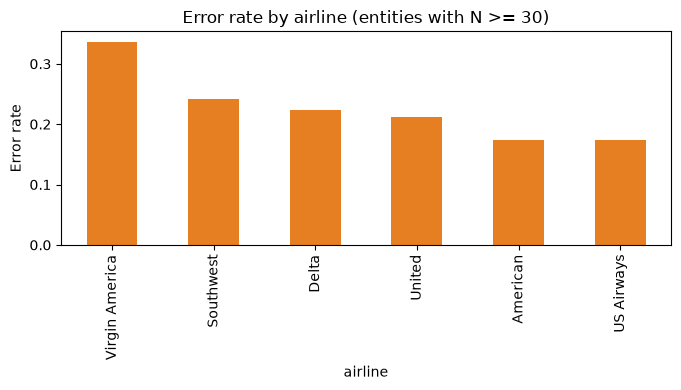

In [55]:
plt.figure(figsize=(7, 4))
entity_error_rate.sort_values(ascending=False).plot(kind='bar', color='#e67e22')
plt.title('Error rate by airline (entities with N >= ' + str(MIN_SUPPORT) + ')')
plt.ylabel('Error rate')
plt.tight_layout()
plt.show()

## 13. Save artifacts and reload check

In [56]:
pred_df.to_csv(os.path.join(OUT, 'test_predictions.csv'), index=False)
joblib.dump(best_model, os.path.join(OUT, 'selected_pipeline.joblib'))

['lab05_outputs/selected_pipeline.joblib']

In [57]:
reloaded = joblib.load(os.path.join(OUT, 'selected_pipeline.joblib'))
check_sample = X_test.iloc[:20]
assert np.array_equal(reloaded.predict(check_sample), best_model.predict(check_sample))
print('Reload check passed')

Reload check passed


## 14. Acceptance tests

In [58]:
assert TEXT_COL in df.columns and TARGET_COL in df.columns
assert df[TARGET_COL].nunique() >= 2
assert not df[TEXT_COL].isna().any()
assert len(set(train_df.index).intersection(set(test_df.index))) == 0
assert all(name in models for name in ['LogisticRegression', 'LinearSVC'])
assert os.path.exists(os.path.join(OUT, 'cv_results.csv'))
assert os.path.exists(os.path.join(OUT, 'selected_pipeline.joblib'))
assert os.path.exists(os.path.join(OUT, 'test_predictions.csv'))
print('Core acceptance tests passed')

Core acceptance tests passed
